# GNN Scheduler Experiment Analysis

This notebook analyzes the results of experiments comparing local execution vs offloading strategies in the GNN scheduler.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (14, 8)

## Loading Results

First, we need to load the simulation results. These will be stored in JSON format from each simulation run.

In [2]:
def load_results(results_folder):
    result_files = [f for f in os.listdir(results_folder) if f.endswith('.json')]
    results = {}
    
    for file in result_files:
        file_path = os.path.join(results_folder, file)
        with open(file_path, 'r') as f:
            results[file] = json.load(f)
    
    return results

local_execution_folder = r"C:\Users\nikol\OneDrive\Documents\TUWien\DSG\my-herosim\analysis\data\results_sim\125-225-5clients-local-with-network"
offload_execution_folder = r"C:\Users\nikol\OneDrive\Documents\TUWien\DSG\my-herosim\analysis\data\results_sim\125-225-5clients-offload-with-network"

local_results = load_results(local_execution_folder)
offload_results = load_results(offload_execution_folder)

## Processing Task Results

We'll extract the task results and convert them to pandas DataFrames for analysis.

In [3]:
def extract_task_metrics(results, experiment_name):
    """Extract task metrics from results into a DataFrame"""
    tasks_data = []
    
    for result_file, result in results.items():
        # Extract task information
        for task in result['stats']['taskResults']:
            task_data = {
                'experiment': experiment_name,
                'task_id': task['taskId'],
                'task_type': task['taskType']['name'],
                'dispatched_time': task['dispatchedTime'],
                'scheduled_time': task['scheduledTime'],
                'arrived_time': task['arrivedTime'],
                'started_time': task['startedTime'],
                'done_time': task['doneTime'],
                'elapsed_time': task['elapsedTime'],
                'queue_time': task['queueTime'],
                'compute_time': task['computeTime'],
                'communications_time': task['communicationsTime'],
                'platform_type': task['platform']['shortName'],
                'local_communications': task['localCommunications'],
                'energy': task['energy'],
                'network_latency': task['networkLatency'],
                'source_node': task['sourceNode'],
                'execution_node': task['executionNode']
            }
            tasks_data.append(task_data)
    
    return pd.DataFrame(tasks_data)

def extract_node_metrics(results, experiment_name):
    """Extract node metrics from results into a DataFrame"""
    nodes_data = []
    
    for result_file, result in results.items():
        # Extract node information
        for node in result['stats']['nodeResults']:
            node_data = {
                'experiment': experiment_name,
                'node_id': node['nodeId'],
                'unused': node['unused'],
                'scheduling_time': node['schedulingTime'],
                'storage_time': node['storageTime'],
                'local_dependencies': node['localDependencies'],
                'cache_hits': node['cacheHits']
            }
            
            # Add energy usage per platform type
            for platform_type, energy in node['energy'].items():
                node_data[f'energy_{platform_type}'] = energy
                
            nodes_data.append(node_data)
    
    return pd.DataFrame(nodes_data)

def extract_summary_metrics(results, experiment_name):
    """Extract summary metrics from results into a DataFrame"""
    summary_data = []
    
    for result_file, result in results.items():
        stats = result['stats']
        summary = {
            'experiment': experiment_name,
            'file': result_file,
            'end_time': stats['endTime'],
            'unused_platforms': stats['unusedPlatforms'],
            'unused_nodes': stats['unusedNodes'],
            'average_occupation': stats['averageOccupation'],
            'average_elapsed_time': stats['averageElapsedTime'],
            'average_queue_time': stats['averageQueueTime'],
            'average_compute_time': stats['averageComputeTime'],
            'average_communications_time': stats['averageCommunicationsTime'],
            'penalty_proportion': stats['penaltyProportion'],
            'local_communications_proportion': stats['localCommunicationsProportion'],
            'total_energy': stats['energy'],
            'avg_network_latency': stats['averageNetworkLatency'],
            'offloading_rate': stats['offloadingRate'],
            'node_pair_latencies': stats['nodePairLatencies']
        }
        summary_data.append(summary)
    
    return pd.DataFrame(summary_data)

local_tasks_df = extract_task_metrics(local_results, 'local')
offload_tasks_df = extract_task_metrics(offload_results, 'offload')
# 
tasks_df = pd.concat([local_tasks_df, offload_tasks_df])
# 
local_nodes_df = extract_node_metrics(local_results, 'local')
offload_nodes_df = extract_node_metrics(offload_results, 'offload')
# 
nodes_df = pd.concat([local_nodes_df, offload_nodes_df])
# 
local_summary_df = extract_summary_metrics(local_results, 'local')
offload_summary_df = extract_summary_metrics(offload_results, 'offload')
# 
summary_df = pd.concat([local_summary_df, offload_summary_df])

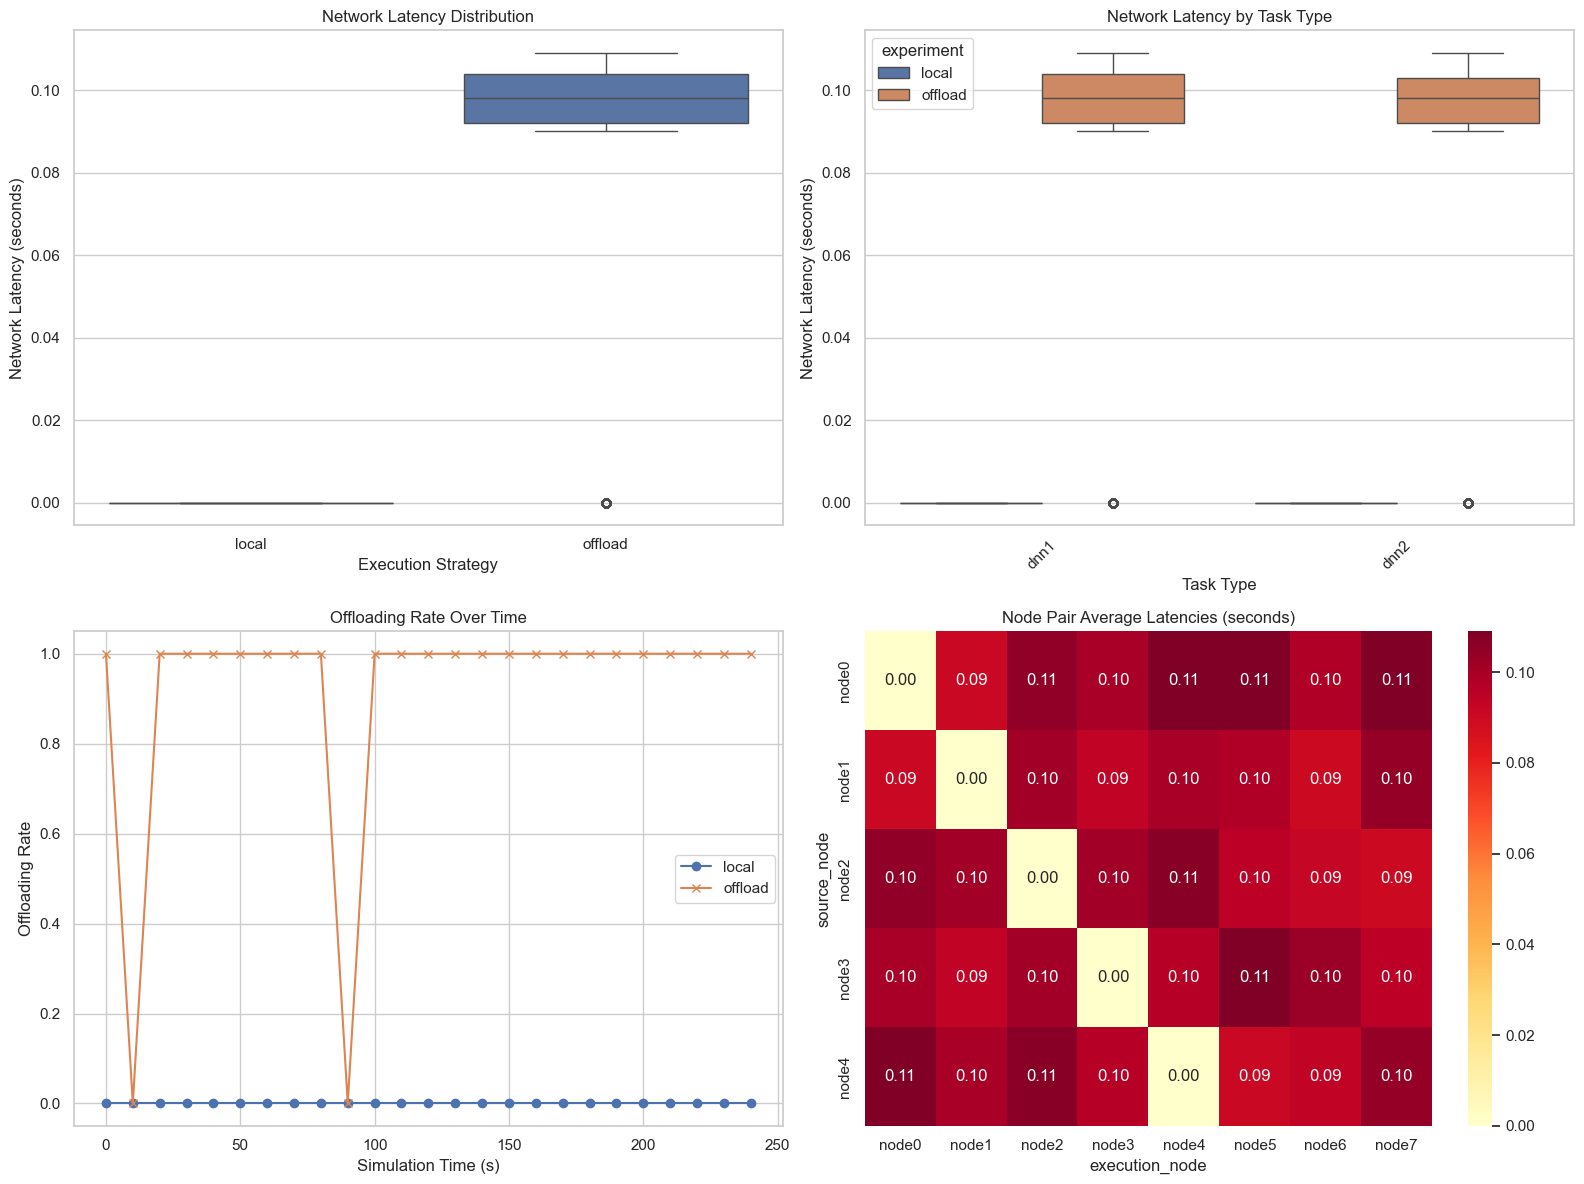


=== Network and Offloading Statistics ===

Average Network Latency by Strategy:
experiment
local      0.000000
offload    0.089489
Name: network_latency, dtype: float64

Offloading Rate by Strategy:
experiment
local       0.00000
offload    89.94158
dtype: float64

Node Pair Average Latencies:
source_node execution_node  network_latency
      node0          node0            0.000
      node0          node1            0.091
      node0          node2            0.105
      node0          node3            0.100
      node0          node4            0.109
      node0          node5            0.109
      node0          node6            0.098
      node0          node7            0.109
      node1          node0            0.091
      node1          node1            0.000
      node1          node2            0.101
      node1          node3            0.094
      node1          node4            0.100
      node1          node5            0.098
      node1          node6            0.090


C:\Users\nikol\AppData\Local\Temp\ipykernel_32304\1142507381.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(tasks_df.groupby('experiment').apply(


In [5]:
def analyze_network_and_offloading(tasks_df):
    """Analyze network latency and offloading patterns"""
    plt.figure(figsize=(16, 12))

    # 1. Network Latency Distribution
    plt.subplot(2, 2, 1)
    sns.boxplot(x='experiment', y='network_latency', data=tasks_df)
    plt.title('Network Latency Distribution')
    plt.xlabel('Execution Strategy')
    plt.ylabel('Network Latency (seconds)')

    # 2. Network Latency by Task Type
    plt.subplot(2, 2, 2)
    sns.boxplot(x='task_type', y='network_latency', hue='experiment', data=tasks_df)
    plt.title('Network Latency by Task Type')
    plt.xlabel('Task Type')
    plt.ylabel('Network Latency (seconds)')
    plt.xticks(rotation=45)

    # 3. Offloading Rate Over Time
    plt.subplot(2, 2, 3)
    # Create time windows
    tasks_df['time_window'] = (tasks_df['dispatched_time'] // 10) * 10

    offload_rate = (tasks_df.groupby(['experiment', 'time_window'])
                   .agg({'source_node': 'first', 'execution_node': 'first'})
                   .reset_index())
    offload_rate['offload_rate'] = offload_rate.apply(
        lambda x: x['source_node'] != x['execution_node'], axis=1
    ).astype(float)

    for exp in tasks_df['experiment'].unique():
        exp_data = offload_rate[offload_rate['experiment'] == exp]
        plt.plot(exp_data['time_window'], exp_data['offload_rate'],
                label=exp, marker='o' if exp=='local' else 'x')
    plt.title('Offloading Rate Over Time')
    plt.xlabel('Simulation Time (s)')
    plt.ylabel('Offloading Rate')
    plt.legend()

    # 4. Node Pair Communication Heatmap
    plt.subplot(2, 2, 4)

    # Create heatmap using tasks_df
    node_pair_latencies = (tasks_df.groupby(['source_node', 'execution_node'])
                          .agg({'network_latency': 'mean'})
                          .reset_index())

    pivot_table = node_pair_latencies.pivot(
        index='source_node',
        columns='execution_node',
        values='network_latency'
    )
    sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='YlOrRd')
    plt.title('Node Pair Average Latencies (seconds)')

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\n=== Network and Offloading Statistics ===")
    print("\nAverage Network Latency by Strategy:")
    print(tasks_df.groupby('experiment')['network_latency'].mean())

    print("\nOffloading Rate by Strategy:")
    print(tasks_df.groupby('experiment').apply(
        lambda x: (x['source_node'] != x['execution_node']).mean() * 100
    ))

    print("\nNode Pair Average Latencies:")
    print(node_pair_latencies.to_string(index=False))

# Run the analysis
analyze_network_and_offloading(tasks_df)

## Analyzing Completion Times

One of the key metrics to analyze is task completion time - how long it takes tasks to complete under different strategies.

count    278672.000000
mean        276.406540
std         392.520700
min           0.044995
25%          51.042956
50%         118.422082
75%         308.589877
max        2543.265898
Name: response_time, dtype: float64


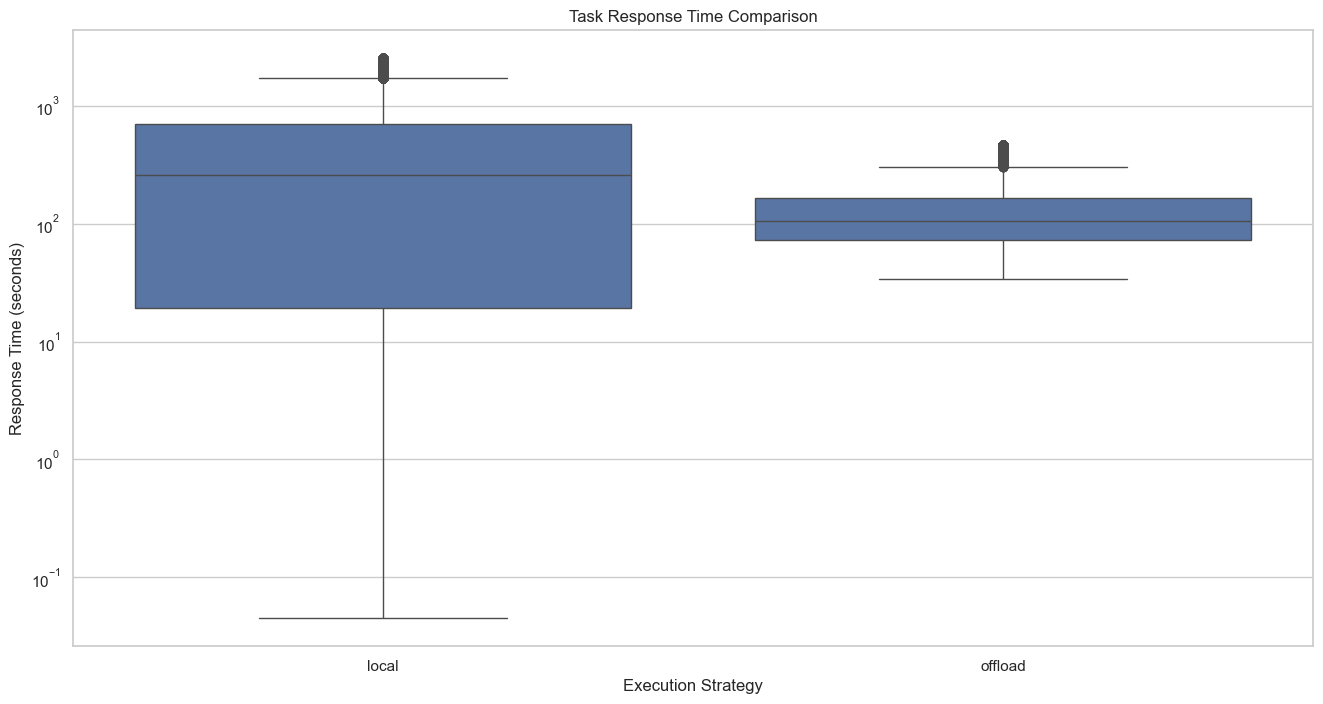

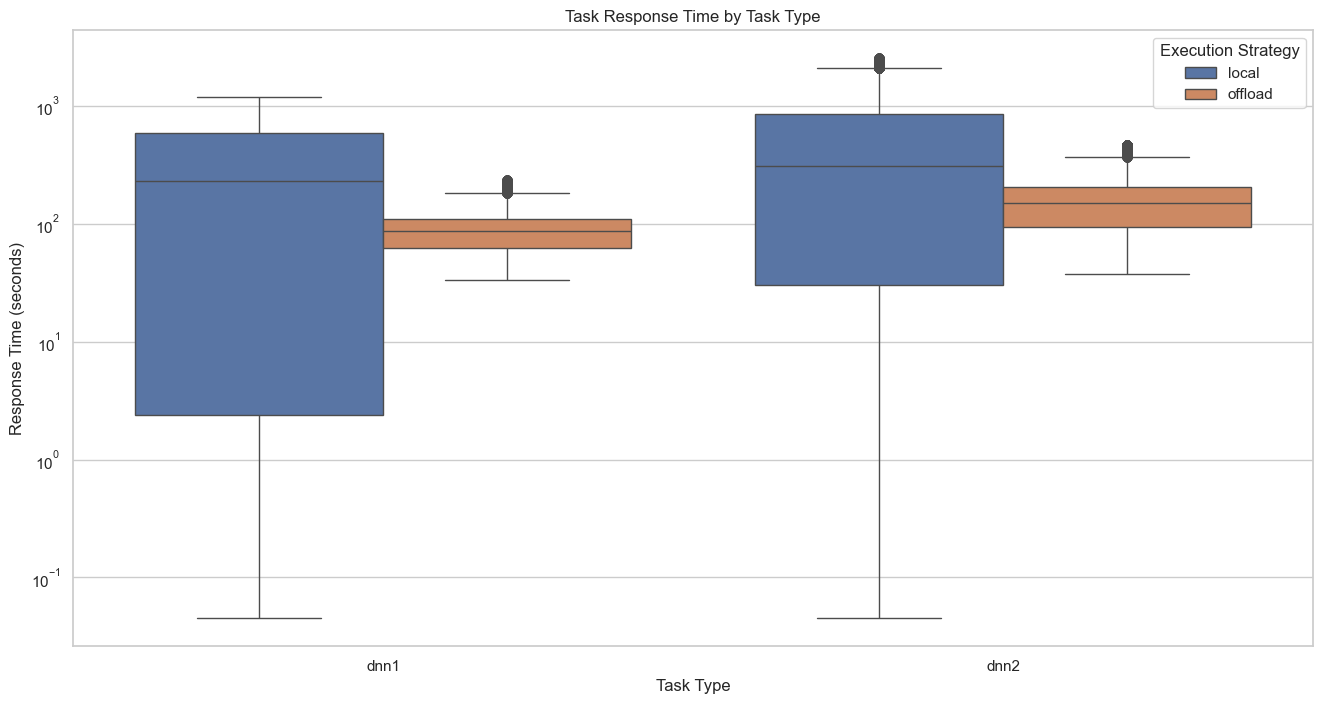

In [6]:
def analyze_task_response_times(tasks_df):
    # Add response time (duration from dispatch to completion)
    tasks_df['response_time'] = tasks_df['done_time'] - tasks_df['dispatched_time']

    print(tasks_df['response_time'].describe())

    plt.figure(figsize=(16, 8))
    sns.boxplot(x='experiment', y='response_time', data=tasks_df)
    plt.yscale('log')
    plt.title('Task Response Time Comparison')
    plt.xlabel('Execution Strategy')
    plt.ylabel('Response Time (seconds)')
    plt.show()

    # Compare by task type
    plt.figure(figsize=(16, 8))
    sns.boxplot(x='task_type', y='response_time', hue='experiment', data=tasks_df)
    plt.yscale('log')
    plt.title('Task Response Time by Task Type')
    plt.xlabel('Task Type')
    plt.ylabel('Response Time (seconds)')
    plt.legend(title='Execution Strategy')
    plt.show()

analyze_task_response_times(tasks_df)

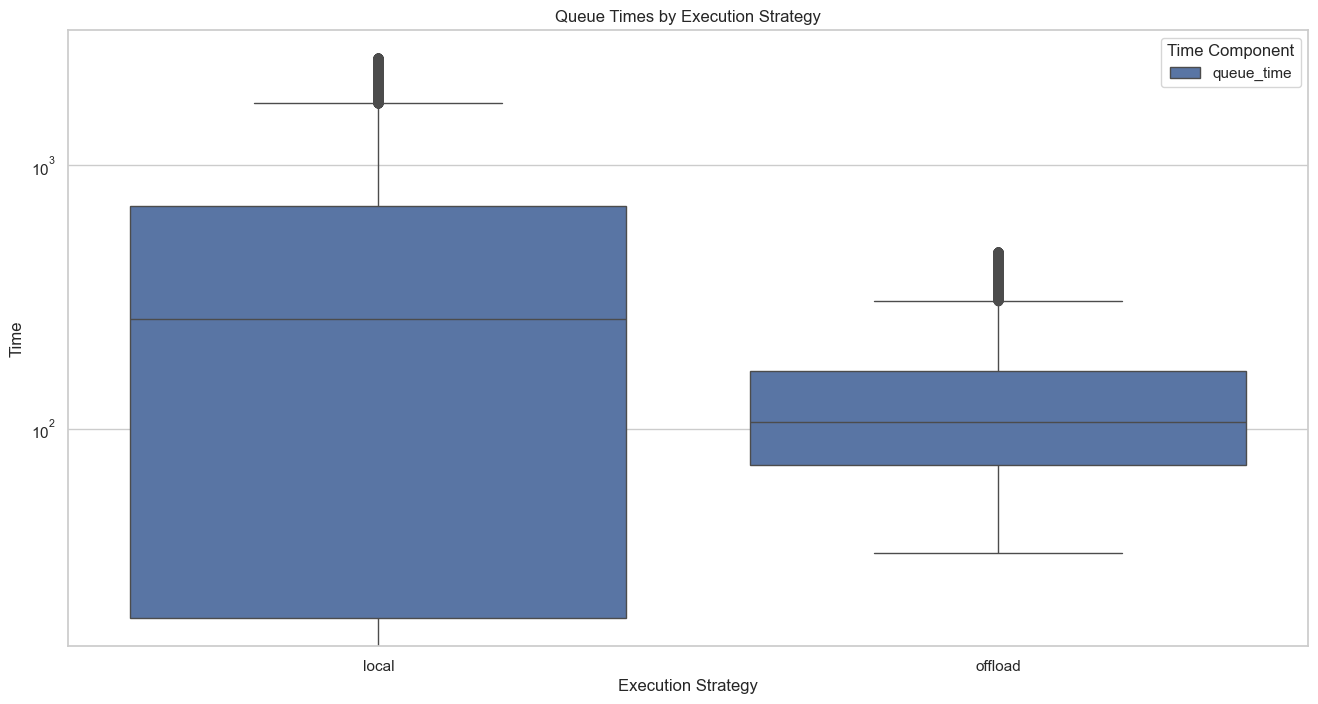

In [7]:
def analyze_queue_times(tasks_df):
    """Analyze task completion times"""
    # Compare queue times vs compute times
    # Create a melted dataframe for plotting
    time_components = tasks_df[['experiment', 'task_id', 'queue_time', 'compute_time', 'communications_time']]
    time_melted = pd.melt(time_components,
                          id_vars=['experiment', 'task_id'],
                          value_vars=['queue_time'],
                          var_name='time_component',
                          value_name='time')

    plt.figure(figsize=(16, 8))
    sns.boxplot(x='experiment', y='time', hue='time_component', data=time_melted)
    plt.title('Queue Times by Execution Strategy')
    plt.xlabel('Execution Strategy')
    plt.ylabel('Time')
    plt.yscale('log')
    plt.legend(title='Time Component')
    plt.show()

analyze_queue_times(tasks_df)

In [8]:
def analyze_completion_times(tasks_df):
    """Analyze task completion times"""
    # Add response time (duration from dispatch to completion)
    tasks_df['response_time'] = tasks_df['done_time'] - tasks_df['dispatched_time']

    print(tasks_df['response_time'].describe())

    # Print summary statistics
    print("Mean Response Times (seconds):")
    print(tasks_df.groupby('experiment')['response_time'].mean())
    print("\nMedian Response Times (seconds):")
    print(tasks_df.groupby('experiment')['response_time'].median())
    print("\nMean Queue Times (seconds):")
    print(tasks_df.groupby('experiment')['queue_time'].mean())

analyze_completion_times(tasks_df)

count    278672.000000
mean        276.406540
std         392.520700
min           0.044995
25%          51.042956
50%         118.422082
75%         308.589877
max        2543.265898
Name: response_time, dtype: float64
Mean Response Times (seconds):
experiment
local      427.19460
offload    125.61848
Name: response_time, dtype: float64

Median Response Times (seconds):
experiment
local      260.451159
offload    106.236696
Name: response_time, dtype: float64

Mean Queue Times (seconds):
experiment
local      427.063503
offload    125.551238
Name: queue_time, dtype: float64


## Analyzing Resource Utilization

Next, let's analyze how resources are utilized under different strategies.

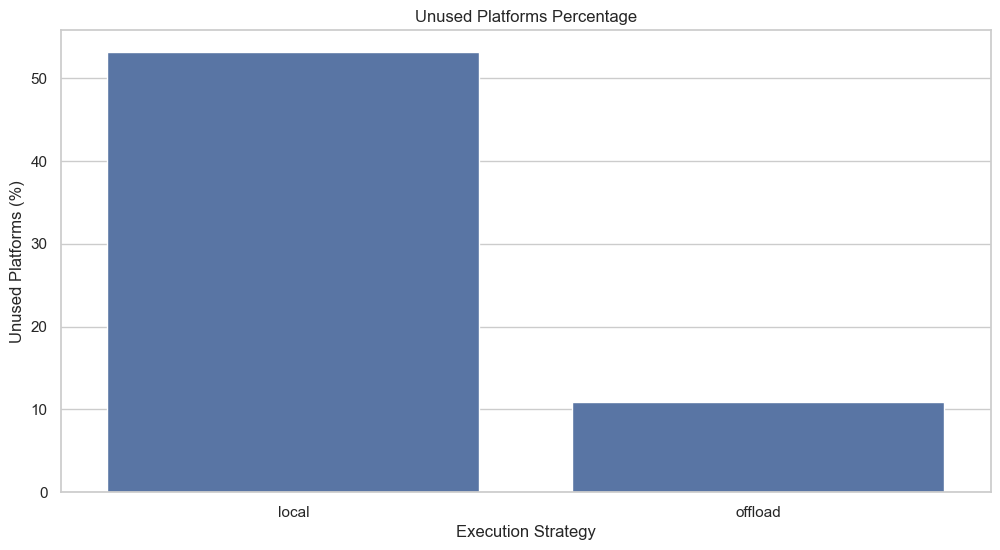

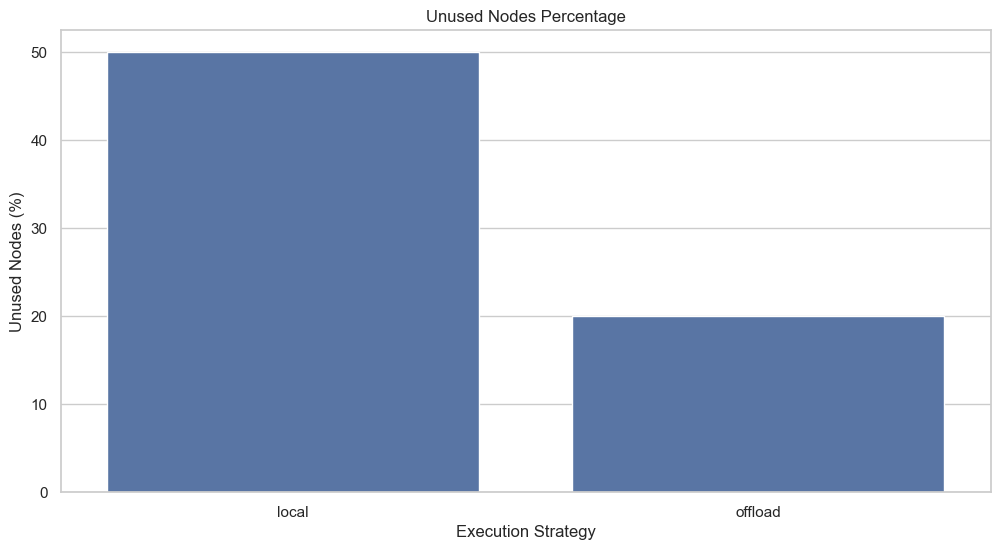

Average Occupation:
experiment
local       8.790937
offload    14.406265
Name: average_occupation, dtype: float64

Unused Platforms Percentage:
experiment
local      53.1250
offload    10.9375
Name: unused_platforms, dtype: float64

Unused Nodes Percentage:
experiment
local      50.0
offload    20.0
Name: unused_nodes, dtype: float64


In [9]:
def analyze_resource_utilization(summary_df):
    """Analyze resource utilization"""
    # Compare platform utilization
    plt.figure(figsize=(12, 6))
    sns.barplot(x='experiment', y='unused_platforms', data=summary_df)
    plt.title('Unused Platforms Percentage')
    plt.xlabel('Execution Strategy')
    plt.ylabel('Unused Platforms (%)')
    plt.show()

    # Compare node utilization
    plt.figure(figsize=(12, 6))
    sns.barplot(x='experiment', y='unused_nodes', data=summary_df)
    plt.title('Unused Nodes Percentage')
    plt.xlabel('Execution Strategy')
    plt.ylabel('Unused Nodes (%)')
    plt.show()

    """
    plt.figure(figsize=(12, 6))
    sns.barplot(x='experiment', y='average_occupation', data=summary_df)
    plt.title('Average Occupation')
    plt.xlabel('Execution Strategy')
    plt.ylabel('Average Occupation')
    plt.show()
    """
    # Print summary statistics
    print("Average Occupation:")
    print(summary_df.groupby('experiment')['average_occupation'].mean())
    print("\nUnused Platforms Percentage:")
    print(summary_df.groupby('experiment')['unused_platforms'].mean())
    print("\nUnused Nodes Percentage:")
    print(summary_df.groupby('experiment')['unused_nodes'].mean())
    
# Example usage
analyze_resource_utilization(summary_df)

## Analyzing Energy Usage

Let's look at energy consumption under different strategies.

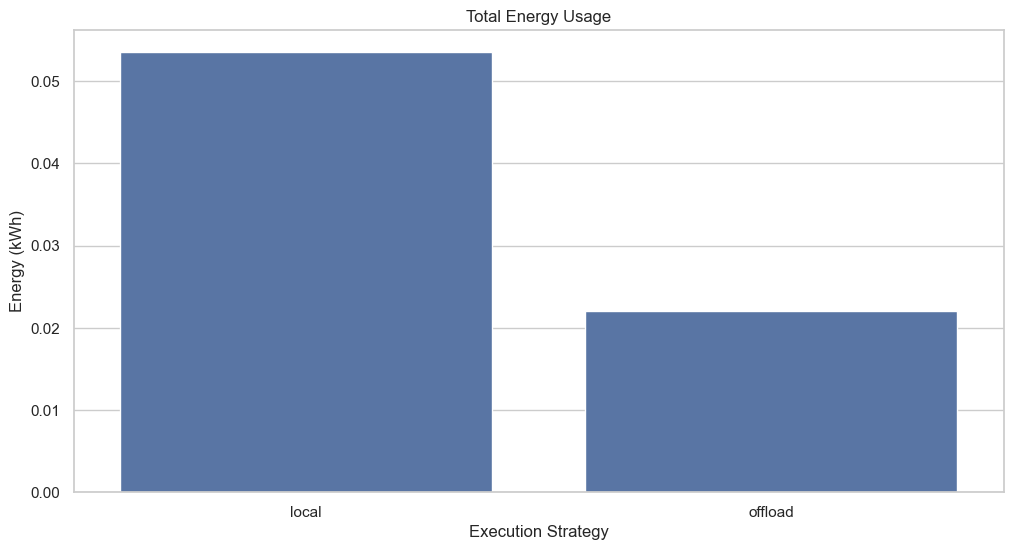

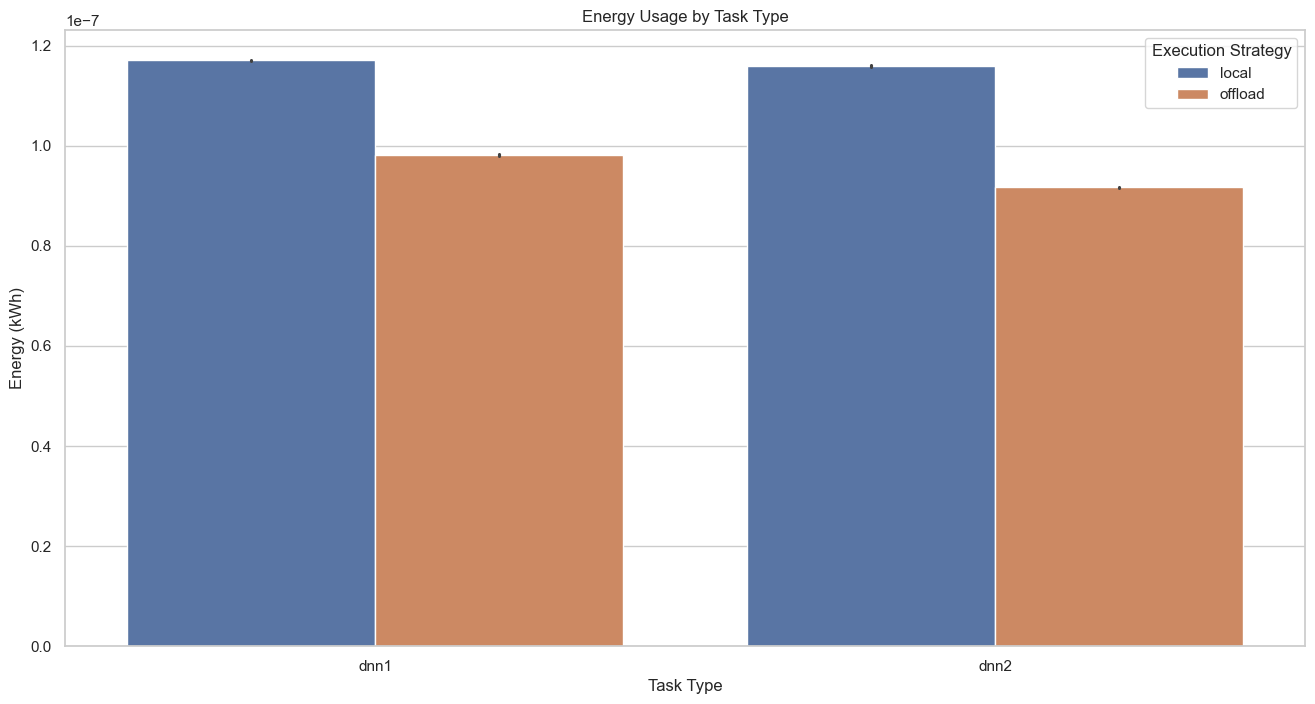

Total Energy (kWh):
experiment
local      0.053536
offload    0.022066
Name: total_energy, dtype: float64

Mean Energy per Task (kWh):
experiment
local      1.164445e-07
offload    9.487090e-08
Name: energy, dtype: float64


In [10]:
def analyze_energy(tasks_df, summary_df):
    """Analyze energy usage"""
    # Compare total energy usage
    plt.figure(figsize=(12, 6))
    sns.barplot(x='experiment', y='total_energy', data=summary_df)
    plt.title('Total Energy Usage')
    plt.xlabel('Execution Strategy')
    plt.ylabel('Energy (kWh)')
    plt.show()
    
    # Energy by task type
    plt.figure(figsize=(16, 8))
    sns.barplot(x='task_type', y='energy', hue='experiment', data=tasks_df)
    plt.title('Energy Usage by Task Type')
    plt.xlabel('Task Type')
    plt.ylabel('Energy (kWh)')
    plt.legend(title='Execution Strategy')
    plt.show()
    
    # Print summary statistics
    print("Total Energy (kWh):")
    print(summary_df.groupby('experiment')['total_energy'].mean())
    print("\nMean Energy per Task (kWh):")
    print(tasks_df.groupby('experiment')['energy'].mean())
    
analyze_energy(tasks_df, summary_df)

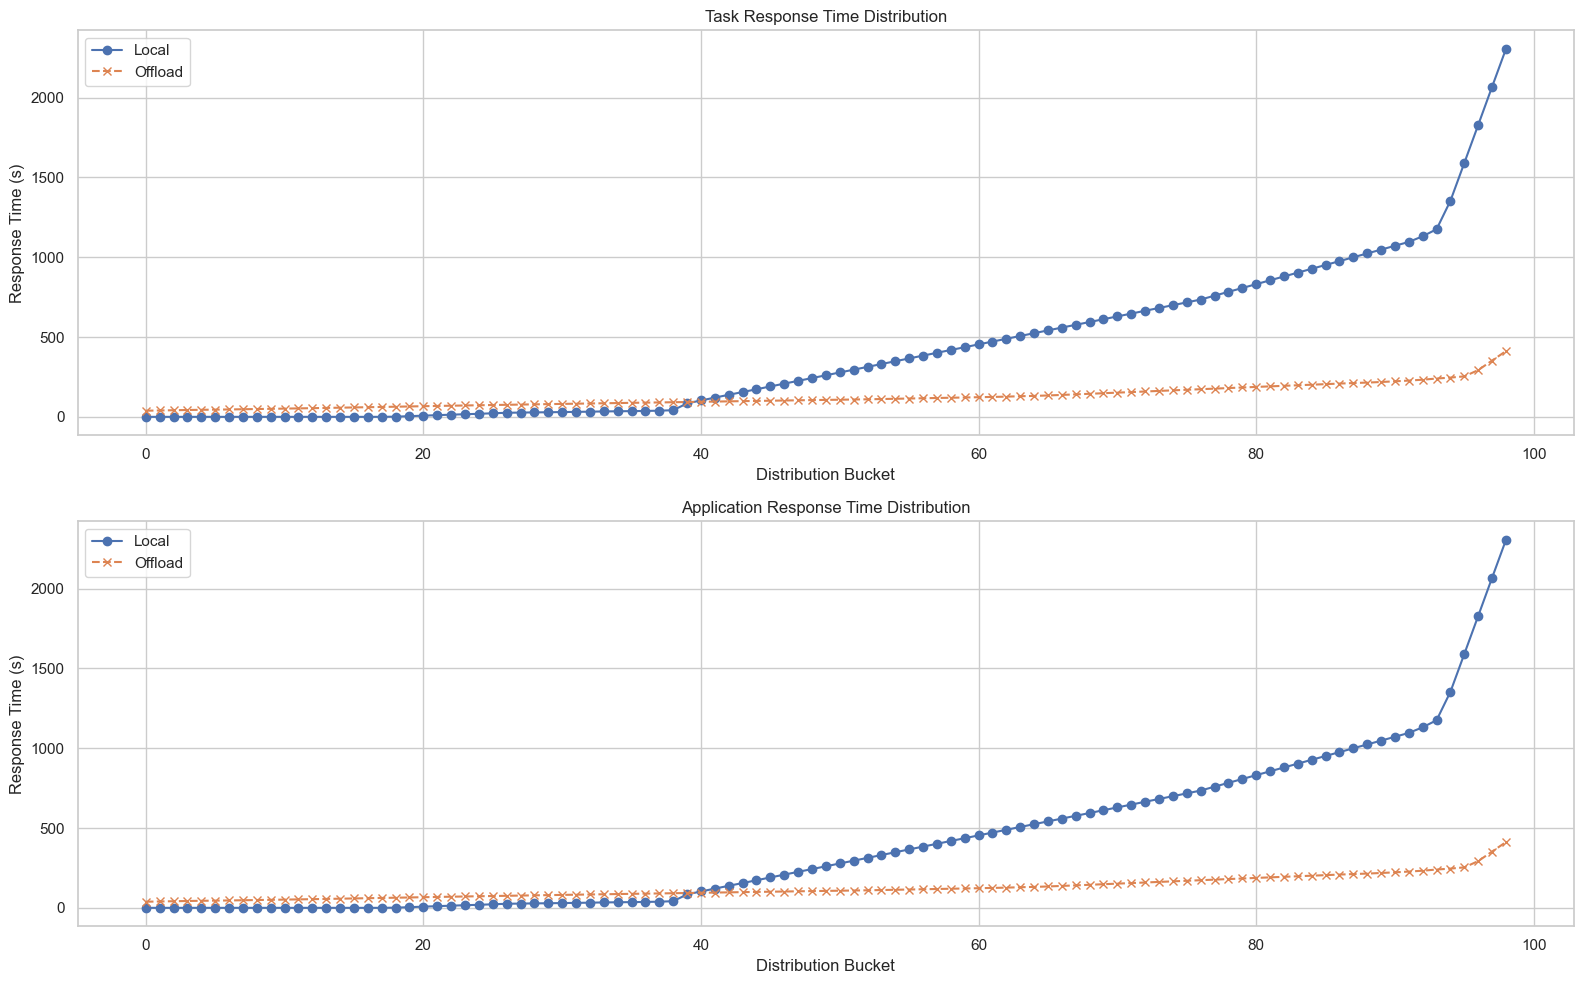

In [11]:
def analyze_response_time_distributions(results, experiment_name):
    """Extract and analyze response time distributions"""
    task_distributions = []
    app_distributions = []

    for result_file, result in results.items():
        stats = result['stats']

        # Task response time distribution
        if 'taskResponseTimeDistribution' in stats:
            # The distribution appears to be a list of values
            task_dist = stats['taskResponseTimeDistribution']
            for i, response_time in enumerate(task_dist):
                task_distributions.append({
                    'experiment': experiment_name,
                    'file': result_file,
                    'bucket': i,
                    'response_time': response_time
                })

        # Application response time distribution
        if 'applicationResponseTimeDistribution' in stats:
            # The distribution appears to be a list of values
            app_dist = stats['applicationResponseTimeDistribution']
            for i, response_time in enumerate(app_dist):
                app_distributions.append({
                    'experiment': experiment_name,
                    'file': result_file,
                    'bucket': i,
                    'response_time': response_time
                })

    return pd.DataFrame(task_distributions), pd.DataFrame(app_distributions)

# Extract distribution data
local_task_dist_df, local_app_dist_df = analyze_response_time_distributions(local_results, 'local')
offload_task_dist_df, offload_app_dist_df = analyze_response_time_distributions(offload_results, 'offload')

# Combine the data
task_dist_df = pd.concat([local_task_dist_df, offload_task_dist_df])
app_dist_df = pd.concat([local_app_dist_df, offload_app_dist_df])

# Visualize response time distributions
plt.figure(figsize=(16, 10))

# Task response time distribution
plt.subplot(2, 1, 1)
for experiment, group in task_dist_df.groupby('experiment'):
    plt.plot(group['bucket'], group['response_time'],
             label=f'{experiment.capitalize()}', marker='o' if experiment=='local' else 'x',
             linestyle='-' if experiment=='local' else '--')

plt.title('Task Response Time Distribution')
plt.xlabel('Distribution Bucket')
plt.ylabel('Response Time (s)')
plt.grid(True)
plt.legend()

# Application response time distribution
plt.subplot(2, 1, 2)
for experiment, group in app_dist_df.groupby('experiment'):
    plt.plot(group['bucket'], group['response_time'],
             label=f'{experiment.capitalize()}', marker='o' if experiment=='local' else 'x',
             linestyle='-' if experiment=='local' else '--')

plt.title('Application Response Time Distribution')
plt.xlabel('Distribution Bucket')
plt.ylabel('Response Time (s)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
def extract_application_metrics(results, experiment_name):
    """Extract application-level metrics from results into a DataFrame"""
    apps_data = []

    for result_file, result in results.items():
        if 'applicationResults' in result['stats']:
            for app in result['stats']['applicationResults']:
                app_data = {
                    'experiment': experiment_name,
                    'file': result_file,
                    'application_id': app['applicationId'],
                    'dispatched_time': app['dispatchedTime'],
                    'elapsed_time': app['elapsedTime'],
                    'pull_time': app.get('pullTime', 0),
                    'cold_start_time': app.get('coldStartTime', 0),
                    'execution_time': app.get('executionTime', 0),
                    'communications_time': app.get('communicationsTime', 0),
                    'penalty': app.get('penalty', False),
                    'app_type': app.get('type', 'unknown'),
                    'platform_type': app.get('platform_type', 'unknown')
                }
                apps_data.append(app_data)

    return pd.DataFrame(apps_data)

# Extract application metrics
local_apps_df = extract_application_metrics(local_results, 'local')
offload_apps_df = extract_application_metrics(offload_results, 'offload')
apps_df = pd.concat([local_apps_df, offload_apps_df])

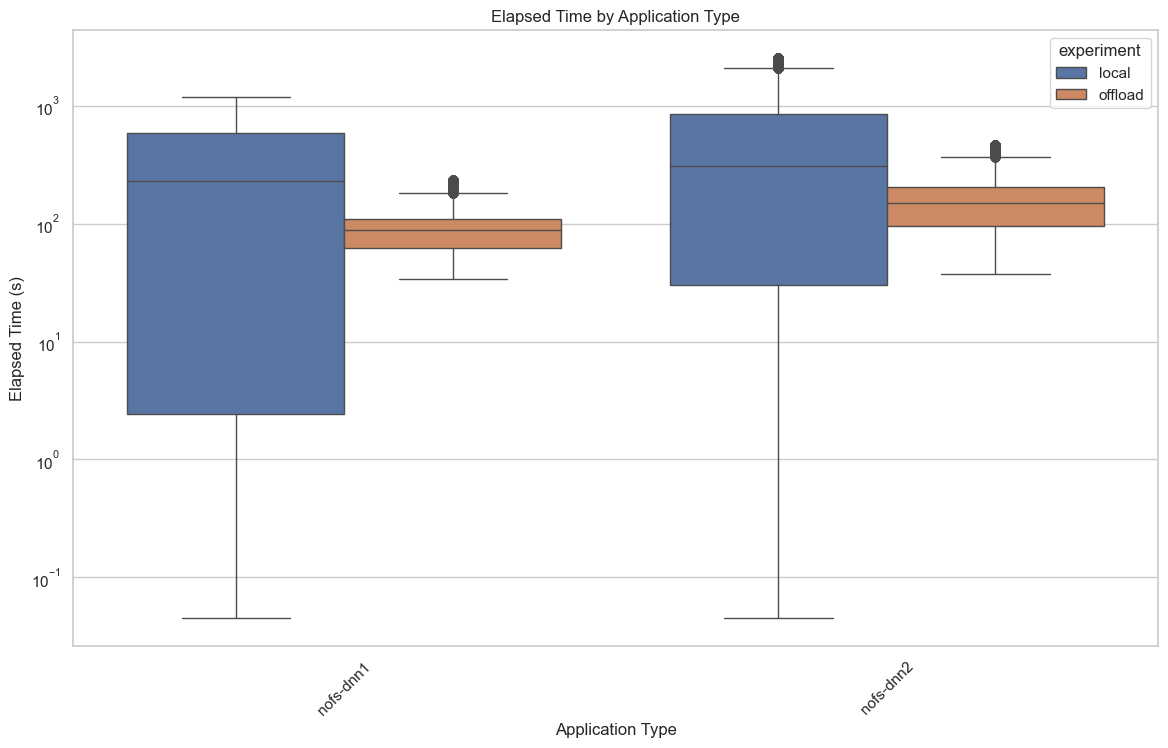

In [13]:
# Elapsed time by application type
sns.boxplot(data=apps_df, x='app_type', y='elapsed_time', hue='experiment')
plt.title('Elapsed Time by Application Type')
plt.xlabel('Application Type')
plt.ylabel('Elapsed Time (s)')
plt.yscale('log')
plt.xticks(rotation=45)

plt.show()

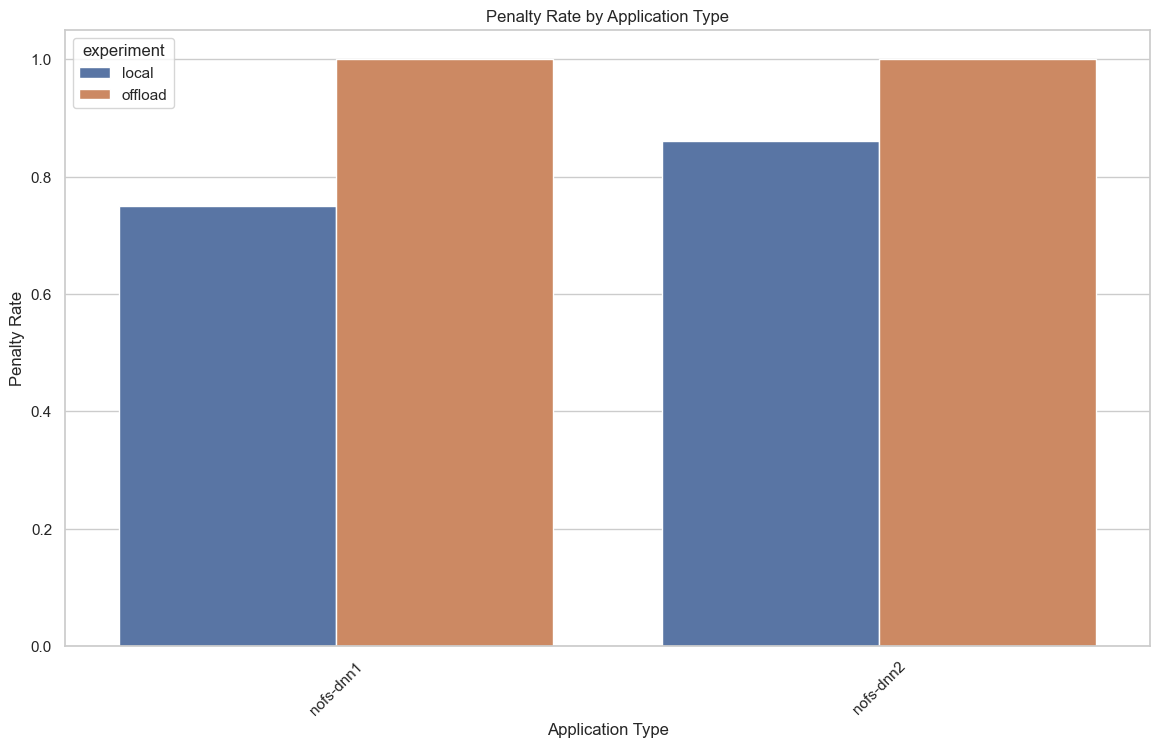

In [14]:
# Penalty rate by experiment
penalty_rate = apps_df.groupby(['experiment', 'app_type'])['penalty'].mean().reset_index()
sns.barplot(data=penalty_rate, x='app_type', y='penalty', hue='experiment')
plt.title('Penalty Rate by Application Type')
plt.xlabel('Application Type')
plt.ylabel('Penalty Rate')
plt.xticks(rotation=45)

plt.show()

In [15]:
def extract_detailed_node_metrics(results, experiment_name):
    """Extract detailed node metrics including platform results"""
    node_data = []
    platform_data = []
    storage_data = []

    for result_file, result in results.items():
        if 'nodeResults' in result['stats']:
            for node in result['stats']['nodeResults']:
                # Basic node metrics
                node_metrics = {
                    'experiment': experiment_name,
                    'file': result_file,
                    'node_id': node['nodeId'],
                    'unused': node.get('unused', False),
                    'scheduling_time': node.get('schedulingTime', 0),
                    'storage_time': node.get('storageTime', 0),
                    'local_dependencies': node.get('localDependencies', 0),
                    'cache_hits': node.get('cacheHits', 0),
                }

                # Energy metrics by platform type
                if 'energy' in node:
                    for platform_type, energy in node['energy'].items():
                        node_metrics[f'energy_{platform_type}'] = energy

                # Idle energy metrics
                if 'energyIdle' in node:
                    for platform_type, energy in node['energyIdle'].items():
                        node_metrics[f'idle_energy_{platform_type}'] = energy

                # Idle time metrics
                if 'idleTime' in node:
                    for platform_type, time_val in node['idleTime'].items():
                        node_metrics[f'idle_time_{platform_type}'] = time_val

                node_data.append(node_metrics)

                # Platform detailed metrics
                if 'platformResults' in node:
                    for platform in node['platformResults']:
                        platform_metrics = {
                            'experiment': experiment_name,
                            'file': result_file,
                            'node_id': node['nodeId'],
                            'platform_id': platform['platformId'],
                            'platform_type': platform['platformType']['shortName'],
                            'platform_hardware': platform['platformType']['hardware'],
                            'platform_price': platform['platformType']['price'],
                            'energy': platform.get('energy', 0),
                            'energy_idle': platform.get('energyIdle', 0),
                            'idle_time': platform.get('idleTime', 0),
                            'idle_proportion': platform.get('idleProportion', 0),
                            'storage_time': platform.get('storageTime', 0)
                        }
                        platform_data.append(platform_metrics)

                # Storage metrics
                if 'storageResults' in node:
                    for storage in node['storageResults']:
                        storage_metrics = {
                            'experiment': experiment_name,
                            'file': result_file,
                            'node_id': node['nodeId'],
                            'storage_id': storage['storageId'],
                            'has_usage_data': len(storage.get('totalUsage', [])) > 0
                        }
                        storage_data.append(storage_metrics)

    return pd.DataFrame(node_data), pd.DataFrame(platform_data), pd.DataFrame(storage_data)

# Extract detailed node metrics
local_node_df, local_platform_df, local_storage_df = extract_detailed_node_metrics(local_results, 'local')
offload_node_df, offload_platform_df, offload_storage_df = extract_detailed_node_metrics(offload_results, 'offload')

# Combine the data
node_df = pd.concat([local_node_df, offload_node_df])
platform_df = pd.concat([local_platform_df, offload_platform_df])
storage_df = pd.concat([local_storage_df, offload_storage_df])

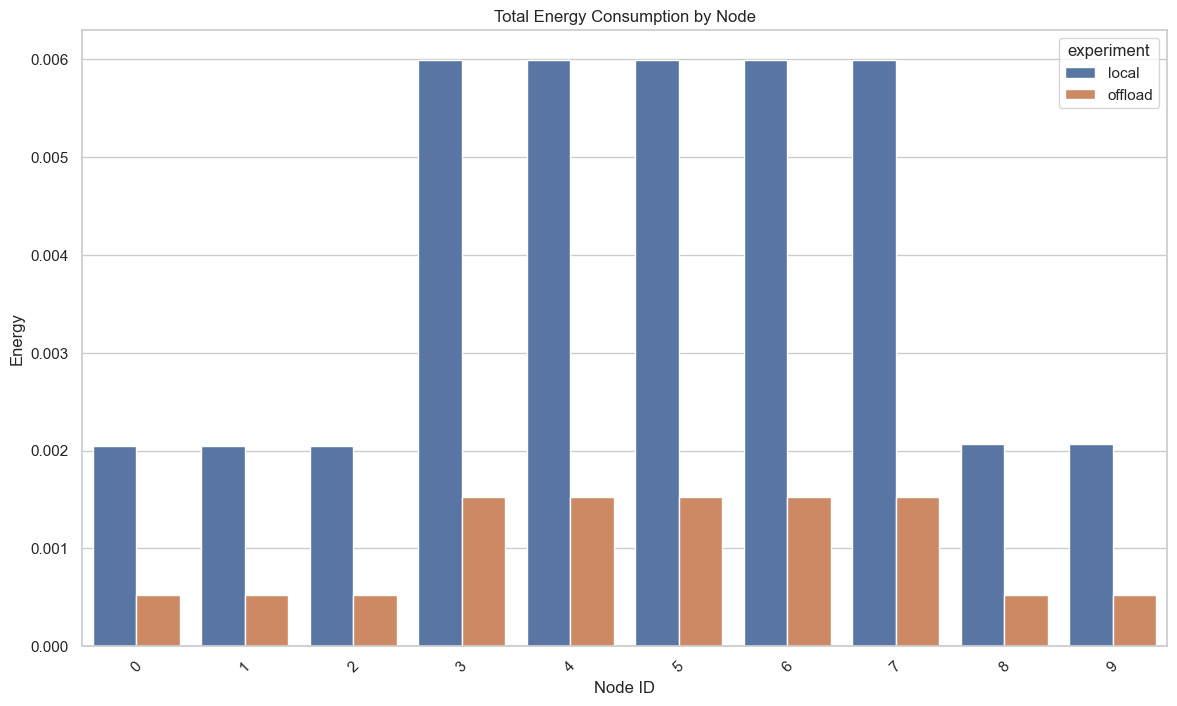

In [16]:
# Node energy consumption by experiment
energy_cols = [col for col in node_df.columns if col.startswith('energy_')]
if energy_cols:
    node_df['total_energy'] = node_df[energy_cols].sum(axis=1)
    sns.barplot(data=node_df, x='node_id', y='total_energy', hue='experiment')
    plt.title('Total Energy Consumption by Node')
    plt.xlabel('Node ID')
    plt.ylabel('Energy')
    plt.xticks(rotation=45)

plt.show()

In [4]:
def extract_detailed_task_metrics(results, experiment_name):
    """Extract detailed task metrics"""
    tasks_data = []

    for result_file, result in results.items():
        if 'taskResults' in result['stats']:
            for task in result['stats']['taskResults']:
                task_data = {
                    'experiment': experiment_name,
                    'file': result_file,
                    'task_id': task['taskId'],
                    'dispatched_time': task['dispatchedTime'],
                    'scheduled_time': task['scheduledTime'],
                    'arrived_time': task['arrivedTime'],
                    'started_time': task['startedTime'],
                    'done_time': task['doneTime'],
                    'task_type': task['taskType']['name'],
                    'platform_type': task['platform']['shortName'],
                    'platform_hardware': task['platform']['hardware'],
                    'elapsed_time': task['elapsedTime'],
                    'pull_time': task.get('pullTime', 0),
                    'cold_start_time': task.get('coldStartTime', 0),
                    'execution_time': task.get('executionTime', 0),
                    'wait_time': task.get('waitTime', 0),
                    'queue_time': task.get('queueTime', 0),
                    'initialization_time': task.get('initializationTime', 0),
                    'compute_time': task.get('computeTime', 0),
                    'communications_time': task.get('communicationsTime', 0),
                    'cold_started': task.get('coldStarted', False),
                    'cache_hit': task.get('cacheHit', False),
                    'local_dependencies': task.get('localDependencies', False),
                    'local_communications': task.get('localCommunications', False),
                    'energy': task.get('energy', 0),
                    'network_latency': task['networkLatency'],
                    'source_node': task['sourceNode'],
                    'execution_node': task['executionNode']
                }

                # Calculate task latency components
                task_data['scheduling_latency'] = task_data['scheduled_time'] - task_data['dispatched_time']
                task_data['arrival_latency'] = task_data['arrived_time'] - task_data['scheduled_time']
                task_data['start_latency'] = task_data['started_time'] - task_data['arrived_time']
                task_data['processing_latency'] = task_data['done_time'] - task_data['started_time']
                task_data['end_to_end_latency'] = task_data['done_time'] - task_data['dispatched_time']

                tasks_data.append(task_data)

    return pd.DataFrame(tasks_data)

# Extract detailed task metrics
local_tasks_df = extract_detailed_task_metrics(local_results, 'local')
offload_tasks_df = extract_detailed_task_metrics(offload_results, 'offload')
tasks_df = pd.concat([local_tasks_df, offload_tasks_df])

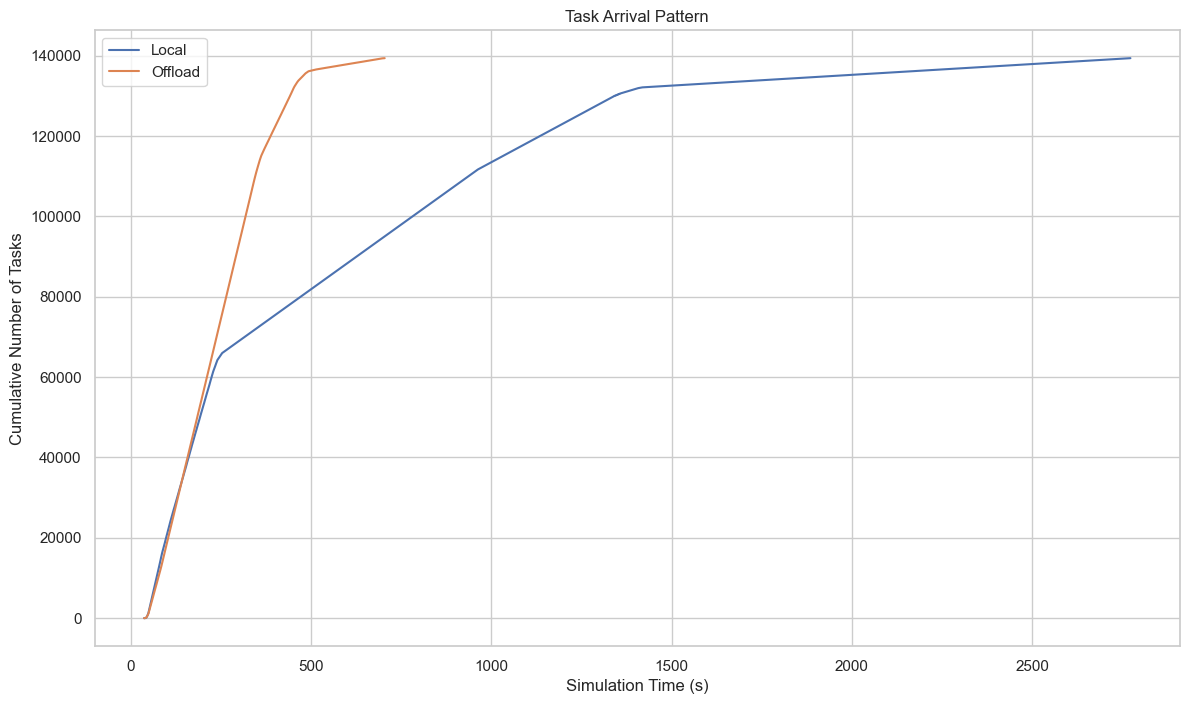

In [18]:
# Task arrival pattern analysis
plt.figure(figsize=(14, 8))
for experiment, group in tasks_df.groupby('experiment'):
    # Sort by arrived time
    group = group.sort_values('arrived_time')
    # Calculate cumulative tasks over time
    times = group['arrived_time'].values
    cumulative_tasks = np.arange(1, len(times) + 1)
    plt.step(times, cumulative_tasks, label=f'{experiment.capitalize()}')

plt.title('Task Arrival Pattern')
plt.xlabel('Simulation Time (s)')
plt.ylabel('Cumulative Number of Tasks')
plt.grid(True)
plt.legend()
plt.show()

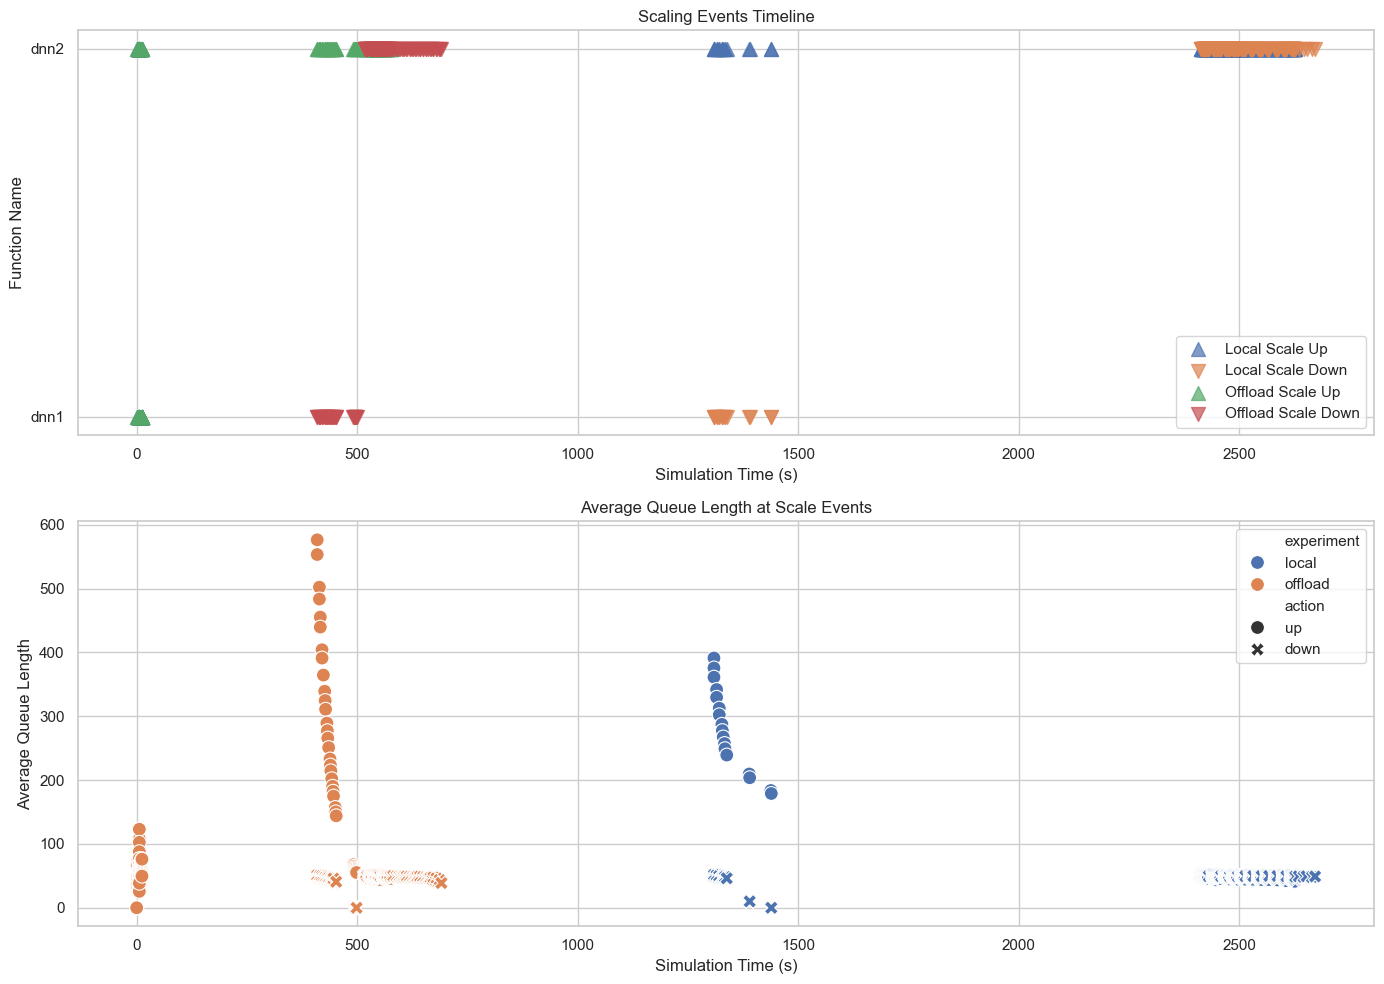

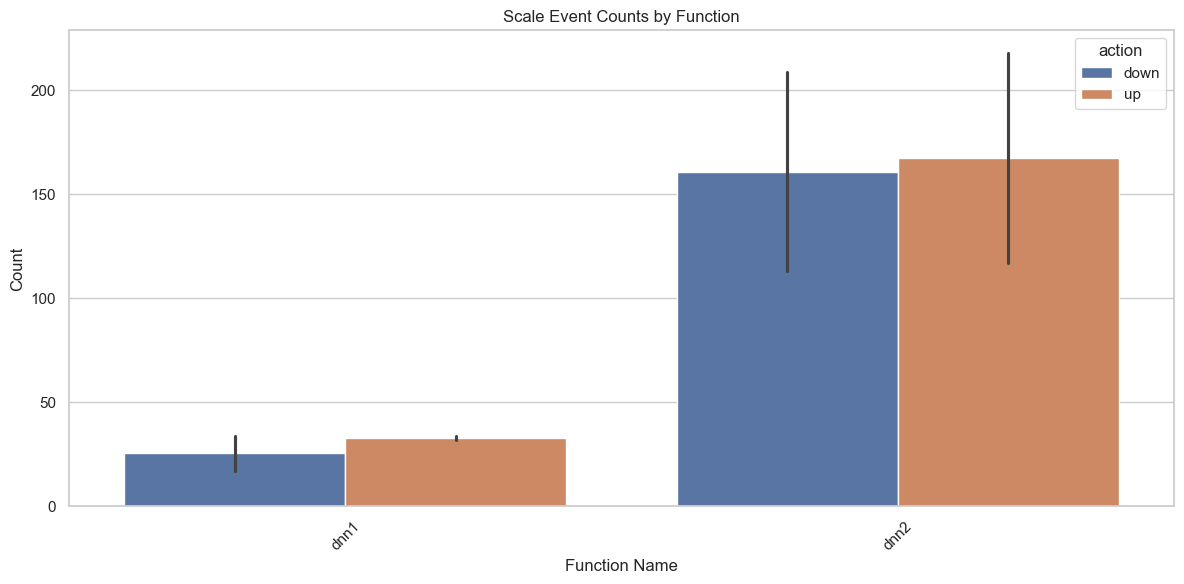

In [19]:
def analyze_scale_events(results, experiment_name):
    """Extract and analyze system scaling events"""
    scale_events = []

    for result_file, result in results.items():
        if 'scaleEvents' in result['stats']:
            for event in result['stats']['scaleEvents']:
                event_data = {
                    'experiment': experiment_name,
                    'file': result_file,
                    'function_name': event['name'],
                    'timestamp': event['timestamp'],
                    'action': event['action'],  # 'up' or 'down'
                    'count': event.get('count', 0),
                    'average_queue_length': event.get('average_queue_length', 0)
                }
                scale_events.append(event_data)

    return pd.DataFrame(scale_events)

# Extract scaling events
local_scale_df = analyze_scale_events(local_results, 'local')
offload_scale_df = analyze_scale_events(offload_results, 'offload')
scale_df = pd.concat([local_scale_df, offload_scale_df])

# Visualize scaling events
plt.figure(figsize=(14, 10))

# Scale events over time
plt.subplot(2, 1, 1)
for experiment, group in scale_df.groupby('experiment'):
    up_events = group[group['action'] == 'up']
    down_events = group[group['action'] == 'down']

    if not up_events.empty:
        plt.scatter(up_events['timestamp'], up_events['function_name'],
                   marker='^', label=f'{experiment.capitalize()} Scale Up',
                   s=100, alpha=0.7)

    if not down_events.empty:
        plt.scatter(down_events['timestamp'], down_events['function_name'],
                   marker='v', label=f'{experiment.capitalize()} Scale Down',
                   s=100, alpha=0.7)

plt.title('Scaling Events Timeline')
plt.xlabel('Simulation Time (s)')
plt.ylabel('Function Name')
plt.grid(True)
plt.legend()

# Queue length at scale events
plt.subplot(2, 1, 2)
if 'average_queue_length' in scale_df.columns:
    sns.scatterplot(data=scale_df, x='timestamp', y='average_queue_length',
                   hue='experiment', style='action', s=100)
    plt.title('Average Queue Length at Scale Events')
    plt.xlabel('Simulation Time (s)')
    plt.ylabel('Average Queue Length')
    plt.grid(True)

plt.tight_layout()
plt.show()

# Scale event counts
plt.figure(figsize=(12, 6))
scale_counts = scale_df.groupby(['experiment', 'function_name', 'action']).size().reset_index(name='count')
sns.barplot(data=scale_counts, x='function_name', y='count', hue='action')
plt.title('Scale Event Counts by Function')
plt.xlabel('Function Name')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
print("=== SUMMARY ===\n")

for exp in tasks_df['experiment'].unique():
    exp_tasks = tasks_df[tasks_df['experiment'] == exp]
    exp_apps = apps_df[apps_df['experiment'] == exp] if 'penalty' in apps_df.columns else None

    print(f"--- {exp.upper()} STRATEGY ---")
    print(f"Total tasks: {len(exp_tasks)}")
    print(f"Average end-to-end latency: {exp_tasks['end_to_end_latency'].mean():.2f} seconds")
    print(f"95th percentile latency: {exp_tasks['end_to_end_latency'].quantile(0.95):.2f} seconds")

    if exp_apps is not None:
        print(f"Application penalty rate: {(exp_apps['penalty'].mean() * 100):.1f}%")

    print()

# Print comparison
if len(tasks_df['experiment'].unique()) > 1:
    local_tasks = tasks_df[tasks_df['experiment'] == 'local']
    offload_tasks = tasks_df[tasks_df['experiment'] == 'offload']

    latency_diff = (offload_tasks['end_to_end_latency'].mean() / local_tasks['end_to_end_latency'].mean() - 1) * 100
    comm_diff = (offload_tasks['communications_time'].mean() / local_tasks['communications_time'].mean() - 1) * 100

    print("--- STRATEGY COMPARISON ---")
    print(f"Offloading is {abs(latency_diff):.1f}% {'slower' if latency_diff > 0 else 'faster'} than local execution")
    print(f"Offloading has {abs(comm_diff):.1f}% {'higher' if comm_diff > 0 else 'lower'} communication overhead")

=== SUMMARY ===

--- LOCAL STRATEGY ---
Total tasks: 139336
Average end-to-end latency: 427.19 seconds
95th percentile latency: 1354.19 seconds
Application penalty rate: 80.5%

--- OFFLOAD STRATEGY ---
Total tasks: 139336
Average end-to-end latency: 125.62 seconds
95th percentile latency: 245.92 seconds
Application penalty rate: 100.0%

--- STRATEGY COMPARISON ---
Offloading is 70.6% faster than local execution
Offloading has 7.7% higher communication overhead


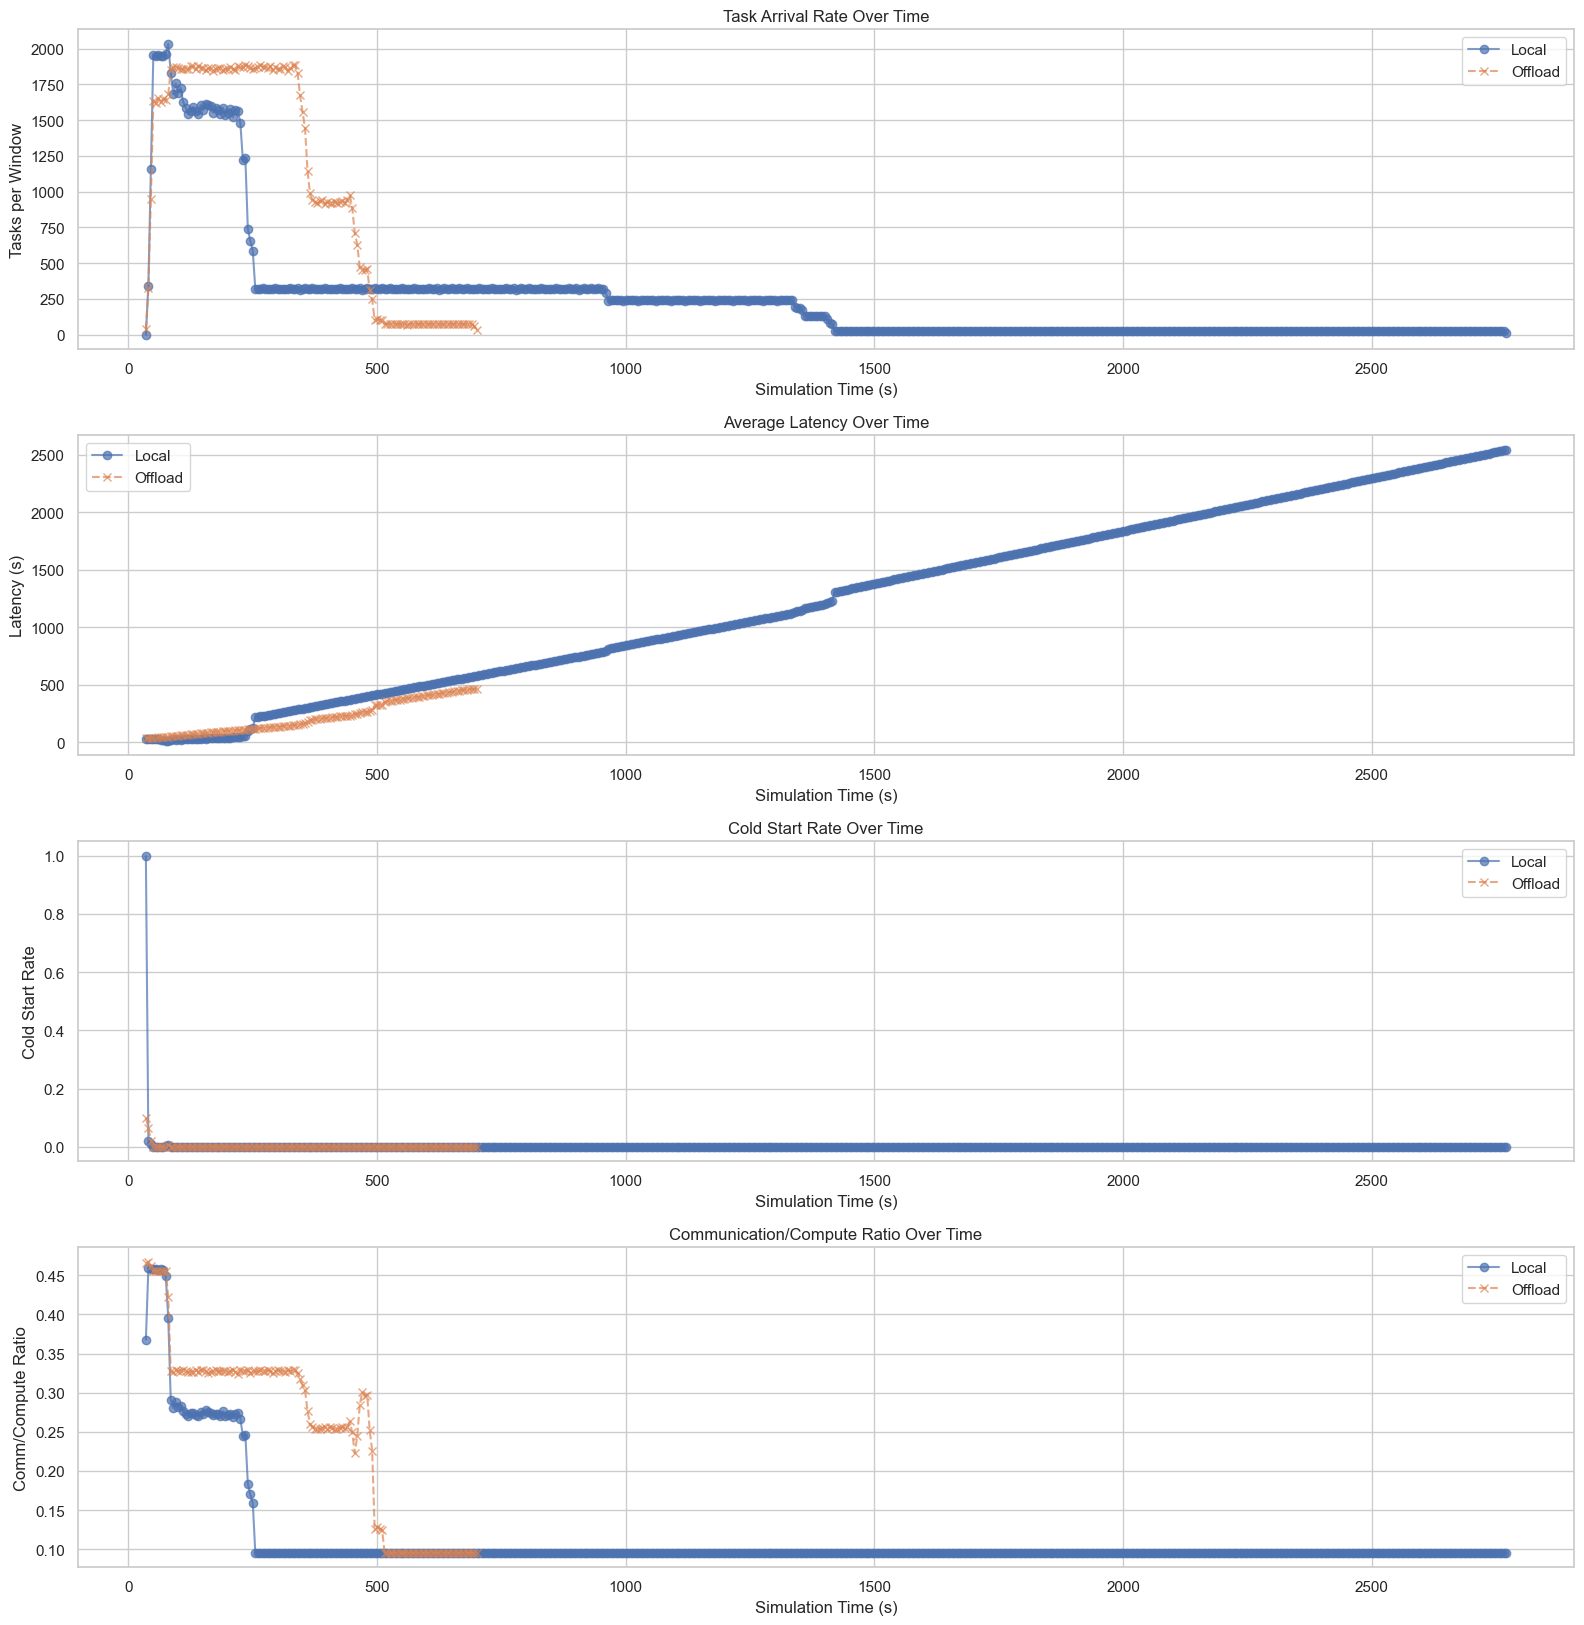

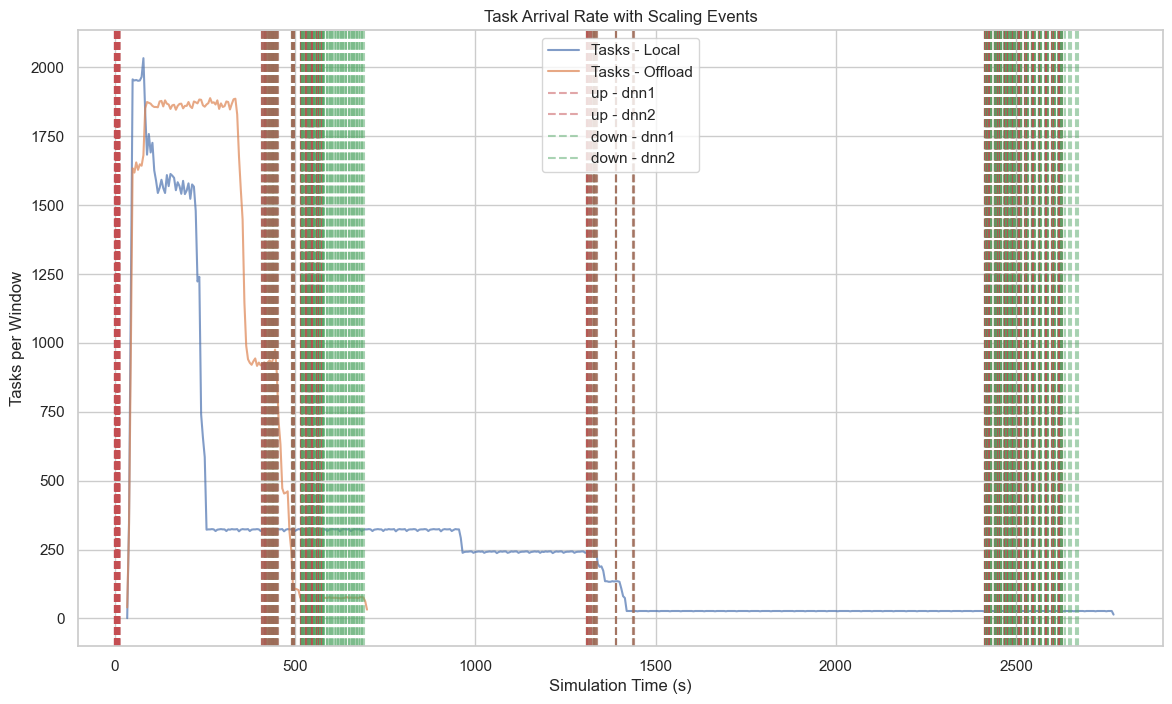

In [21]:
def time_series_analysis(tasks_df, scale_df):
    """Perform time-series analysis of system behavior"""
    # Create time windows (e.g., 5-second intervals)
    time_window = 5
    tasks_df['time_window'] = (tasks_df['arrived_time'] // time_window) * time_window

    # Calculate metrics per window
    ts_metrics = tasks_df.groupby(['experiment', 'time_window']).agg({
        'task_id': 'count',
        'end_to_end_latency': 'mean',
        'cold_started': 'mean',
        'local_communications': 'mean',
        'communications_time': 'mean',
        'compute_time': 'mean'
    }).reset_index()

    ts_metrics.rename(columns={
        'task_id': 'task_count',
        'cold_started': 'cold_start_rate',
        'local_communications': 'local_comm_rate'
    }, inplace=True)

    # Plot time series metrics
    plt.figure(figsize=(16, 20))

    # Task arrival rate
    plt.subplot(5, 1, 1)
    for experiment, group in ts_metrics.groupby('experiment'):
        plt.plot(group['time_window'], group['task_count'],
                 label=f'{experiment.capitalize()}', marker='o' if experiment=='local' else 'x',
                 linestyle='-' if experiment=='local' else '--', alpha=0.7)
    plt.title('Task Arrival Rate Over Time')
    plt.xlabel('Simulation Time (s)')
    plt.ylabel('Tasks per Window')
    plt.grid(True)
    plt.legend()

    # Average latency
    plt.subplot(5, 1, 2)
    for experiment, group in ts_metrics.groupby('experiment'):
        plt.plot(group['time_window'], group['end_to_end_latency'],
                 label=f'{experiment.capitalize()}', marker='o' if experiment=='local' else 'x',
                 linestyle='-' if experiment=='local' else '--', alpha=0.7)
    plt.title('Average Latency Over Time')
    plt.xlabel('Simulation Time (s)')
    plt.ylabel('Latency (s)')
    plt.grid(True)
    plt.legend()

    # Cold start rate
    plt.subplot(5, 1, 3)
    for experiment, group in ts_metrics.groupby('experiment'):
        plt.plot(group['time_window'], group['cold_start_rate'],
                 label=f'{experiment.capitalize()}', marker='o' if experiment=='local' else 'x',
                 linestyle='-' if experiment=='local' else '--', alpha=0.7)
    plt.title('Cold Start Rate Over Time')
    plt.xlabel('Simulation Time (s)')
    plt.ylabel('Cold Start Rate')
    plt.grid(True)
    plt.legend()

    # Communication/Compute ratio
    plt.subplot(5, 1, 4)
    ts_metrics['comm_compute_ratio'] = ts_metrics['communications_time'] / ts_metrics['compute_time']
    for experiment, group in ts_metrics.groupby('experiment'):
        plt.plot(group['time_window'], group['comm_compute_ratio'],
                 label=f'{experiment.capitalize()}', marker='o' if experiment=='local' else 'x',
                 linestyle='-' if experiment=='local' else '--', alpha=0.7)
    plt.title('Communication/Compute Ratio Over Time')
    plt.xlabel('Simulation Time (s)')
    plt.ylabel('Comm/Compute Ratio')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Overlay scaling events if available
    if not scale_df.empty:
        plt.figure(figsize=(14, 8))

        # Plot task count
        for experiment, group in ts_metrics.groupby('experiment'):
            plt.plot(group['time_window'], group['task_count'],
                     label=f'Tasks - {experiment.capitalize()}',
                     linestyle='-', alpha=0.7)

        # Overlay scale events as vertical lines
        for experiment, group in scale_df.groupby('experiment'):
            for _, event in group.iterrows():
                plt.axvline(x=event['timestamp'], color='r' if event['action'] == 'up' else 'g',
                           linestyle='--', alpha=0.5,
                           label=f"{event['action']} - {event['function_name']}")

        plt.title('Task Arrival Rate with Scaling Events')
        plt.xlabel('Simulation Time (s)')
        plt.ylabel('Tasks per Window')
        plt.grid(True)

        # Handle duplicate labels in legend
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        plt.legend(by_label.values(), by_label.keys())

        plt.show()

    return ts_metrics

# Run time series analysis
ts_metrics = time_series_analysis(tasks_df, scale_df)

# Reset extraction

In [22]:
# nichts

# GNN implementation

In [27]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
import numpy as np
import time

def prepare_gnn_training_data(tasks_df, batch_size=1024):
    """Prepare training data for the GNN scheduler with efficient batching"""
    print("Preparing node mappings...")
    # Create node feature mapping
    unique_nodes = np.union1d(tasks_df['source_node'].unique(),
                            tasks_df['execution_node'].unique())
    node_to_idx = {node: idx for idx, node in enumerate(unique_nodes)}

    print(f"Found {len(unique_nodes)} unique nodes")

    print("Encoding task types...")
    # Encode task types
    task_types = tasks_df['task_type'].unique()
    task_encoder = {task: idx for idx, task in enumerate(task_types)}
    print(f"Found {len(task_types)} unique task types")

    print("Normalizing features...")
    # Normalize numeric features
    scaler = StandardScaler()

    tasks_df_processed = tasks_df.copy()
    tasks_df_processed['network_latency_scaled'] = scaler.fit_transform(tasks_df[['network_latency']])
    tasks_df_processed['compute_time_scaled'] = scaler.fit_transform(tasks_df[['compute_time']])
    tasks_df_processed['task_type_encoded'] = tasks_df['task_type'].map(task_encoder)

    # Create positive examples from actual scheduling decisions
    positive_examples = tasks_df_processed[['source_node', 'execution_node', 'network_latency_scaled',
                              'compute_time_scaled', 'task_type_encoded']].copy()
    positive_examples['label'] = 1

    return positive_examples, node_to_idx, task_encoder, scaler

In [60]:


from src.notebooks.scheduler_gnn import SchedulerGNN

"""
class SchedulerGNN(torch.nn.Module):
    def __init__(self, num_node_features, num_task_features, hidden_channels=32):
        super().__init__()
        self.num_node_features = num_node_features
        self.num_task_features = num_task_features
        self.hidden_channels = hidden_channels

        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.mlp = torch.nn.Sequential(
            torch.nn.Linear(hidden_channels + num_task_features, hidden_channels),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_channels, 1)
        )

    def forward(self, x, edge_index, edge_attr, task_features):
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index, edge_attr)
        x = torch.cat([x, task_features], dim=1)
        return torch.sigmoid(self.mlp(x)).squeeze()

    @classmethod
    def load(cls, path, num_node_features, num_task_features, device='cpu'):
        model = cls(num_node_features, num_task_features)
        model.load_state_dict(torch.load(path, map_location=device))
        model.eval().to(device)
        return model
"""

"import torch\nimport torch.nn.functional as F\nfrom torch_geometric.nn import GCNConv\n\nclass SchedulerGNN(torch.nn.Module):\n    def __init__(self, num_node_features, num_task_features, hidden_channels=32):\n        super().__init__()\n        self.num_node_features = num_node_features\n        self.num_task_features = num_task_features\n        self.hidden_channels = hidden_channels\n\n        self.conv1 = GCNConv(num_node_features, hidden_channels)\n        self.conv2 = GCNConv(hidden_channels, hidden_channels)\n        self.mlp = torch.nn.Sequential(\n            torch.nn.Linear(hidden_channels + num_task_features, hidden_channels),\n            torch.nn.ReLU(),\n            torch.nn.Linear(hidden_channels, 1)\n        )\n\n    def forward(self, x, edge_index, edge_attr, task_features):\n        x = self.conv1(x, edge_index, edge_attr)\n        x = F.relu(x)\n        x = F.dropout(x, p=0.5, training=self.training)\n        x = self.conv2(x, edge_index, edge_attr)\n        x = tor

In [45]:
def create_graph_data(training_data_df, node_to_idx):
    """Convert training data into PyTorch Geometric graph data objects"""
    graphs = []

    total_rows = len(training_data_df)
    print(f"Total training samples: {total_rows}")

    start_time = time.time()
    timing_samples = 10000

    # precompute latency lookup
    latency_lookup = training_data_df.groupby(['source_node', 'execution_node'])['network_latency_scaled'].mean().to_dict()

    for idx, (_, row) in enumerate(training_data_df.iterrows()):
        start_time_loop = time.time()
        # Create node features (one-hot)
        num_nodes = len(node_to_idx)
        x = torch.eye(num_nodes)

        # Create edge index and features
        edge_index = []
        edge_attr = []
        for source in node_to_idx.keys():
            for target in node_to_idx.keys():
                if source != target:
                    edge_index.append([node_to_idx[source], node_to_idx[target]])
                    latency = latency_lookup.get((source, target), 0)
                    edge_attr.append([latency if not np.isnan(latency) else 0])

        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attr, dtype=torch.float)

        # Create task features
        task_features = torch.tensor([
            row['task_type_encoded'],
            row['compute_time_scaled']
        ], dtype=torch.float).repeat(num_nodes, 1)

        # Create target
        y = torch.zeros(num_nodes)
        y[node_to_idx[row['execution_node']]] = row['label']

        # Create graph data object
        data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
                    task_features=task_features, y=y)
        graphs.append(data)

        if idx + 1 == timing_samples:
            elapsed_time = time.time() - start_time
            avg_time = elapsed_time / timing_samples
            estimated_total = avg_time * total_rows
            print(f"First {timing_samples} iterations took {elapsed_time:.2f} seconds.")
            print(f"Average time per graph: {avg_time:.4f} seconds.")
            print(f"Estimated total time: {estimated_total:.2f} seconds ({estimated_total/60:.2f} minutes).")

        if idx >= len(training_data_df) - 1:
            print(f"Actual total time: {time.time() - start_time:.2f} seconds.")

    return graphs

In [46]:
# Prepare training data
print("Preparing training data...")
training_data, node_to_idx, task_encoder, scaler = prepare_gnn_training_data(tasks_df)
print("Creating graph data...")
graph_data = create_graph_data(training_data, node_to_idx)

Preparing training data...
Preparing node mappings...
Found 8 unique nodes
Encoding task types...
Found 2 unique task types
Normalizing features...
Creating graph data...
Total training samples: 278672
First 10000 iterations took 4.47 seconds.
Average time per graph: 0.0004 seconds.
Estimated total time: 124.57 seconds (2.08 minutes).
Actual total time: 116.72 seconds.


In [56]:
import logging
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

# Setup logger
# todo: use logger
logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("training.log"),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger()

def train_model(model, all_graphs, optimizer, epochs=10, batch_size=16, checkpoint_path='model_checkpoint.pt'):
    """Train the GNN model with logging, validation, checkpointing, and GPU support"""

    print(f"Splitting {len(all_graphs)} graphs into train/val sets...")
    train_graphs, val_graphs = train_test_split(all_graphs, test_size=0.2, random_state=42)

    train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_graphs, batch_size=batch_size, shuffle=False, num_workers=0)

    # Just to test if DataLoader is responsive
    for i, batch in enumerate(train_loader):
        print(f"Got batch {i}, x shape: {batch.x.shape}")
        break

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    print(f"Using device: {device}")

    best_val_loss = float('inf')
    loss_history, val_loss_history = [], []
    acc_history, val_acc_history = [], []

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs} starting...")
        epoch_start = time.time()

        # === TRAIN ===
        model.train()
        total_loss, correct, total = 0, 0, 0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} - Training", bar_format='{l_bar}{bar:10}{r_bar}{bar:-10b}'):
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch.x, batch.edge_index, batch.edge_attr, batch.task_features)
            loss = F.binary_cross_entropy(out, batch.y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred = (out > 0.5).float()
            correct += (pred == batch.y).sum().item()
            total += len(batch.y)

        avg_loss = total_loss / len(train_loader)
        acc = correct / total
        loss_history.append(avg_loss)
        acc_history.append(acc)

        # === VALIDATION ===
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1} - Validation"):
                batch = batch.to(device)
                out = model(batch.x, batch.edge_index, batch.edge_attr, batch.task_features)
                loss = F.binary_cross_entropy(out, batch.y)

                val_loss += loss.item()
                pred = (out > 0.5).float()
                val_correct += (pred == batch.y).sum().item()
                val_total += len(batch.y)

        val_avg_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total
        val_loss_history.append(val_avg_loss)
        val_acc_history.append(val_acc)

        if val_avg_loss < best_val_loss:
            best_val_loss = val_avg_loss
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Best model saved (Val Loss: {val_avg_loss:.4f})")

        epoch_time = time.time() - epoch_start
        print(
            f"Epoch {epoch+1:03d} Summary | Train Loss: {avg_loss:.4f}, Acc: {acc:.4f} | "
            f"Val Loss: {val_avg_loss:.4f}, Acc: {val_acc:.4f} | Time: {epoch_time:.2f}s"
        )

    print("Training Complete.")

    # === PLOT METRICS ===
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(loss_history, label="Train Loss")
    plt.plot(val_loss_history, label="Val Loss")
    plt.title("Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(acc_history, label="Train Acc")
    plt.plot(val_acc_history, label="Val Acc")
    plt.title("Accuracy over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

[2025-05-27 12:01:22,676] INFO - Splitting 278672 graphs into train/val sets...
[2025-05-27 12:01:22,798] INFO - Using device: cpu
[2025-05-27 12:01:22,798] INFO - Epoch 1/10 starting...


Training model...
Got batch 0, x shape: torch.Size([128, 8])


Epoch 1 - Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3484/3484 [00:24<00:00, 139.53it/s]
[2025-05-27 12:04:32,548] INFO - Best model saved (Val Loss: 0.3529)
[2025-05-27 12:04:32,549] INFO - Epoch 001 Summary | Train Loss: 0.3552, Acc: 0.8750 | Val Loss: 0.3529, Acc: 0.8750 | Time: 189.74s
[2025-05-27 12:04:32,549] INFO - Epoch 2/10 starting...
Epoch 2 - Validation: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3484/3484 [00:16<00:00, 209.79it/s]
[2025-05-27 12:09:32,102] INFO - Epoch 002 Summary | Train Loss: 0.3562, Acc: 0.8750 | Val Loss: 0.3565, Acc: 0.8750 | Time: 299.55s
[2025-05-27 12:09:32,102] INFO - Epoch 3/10 starting...
Epoch 3 - Validation: 100%|██████████████████████████████████████████████████████████████████████

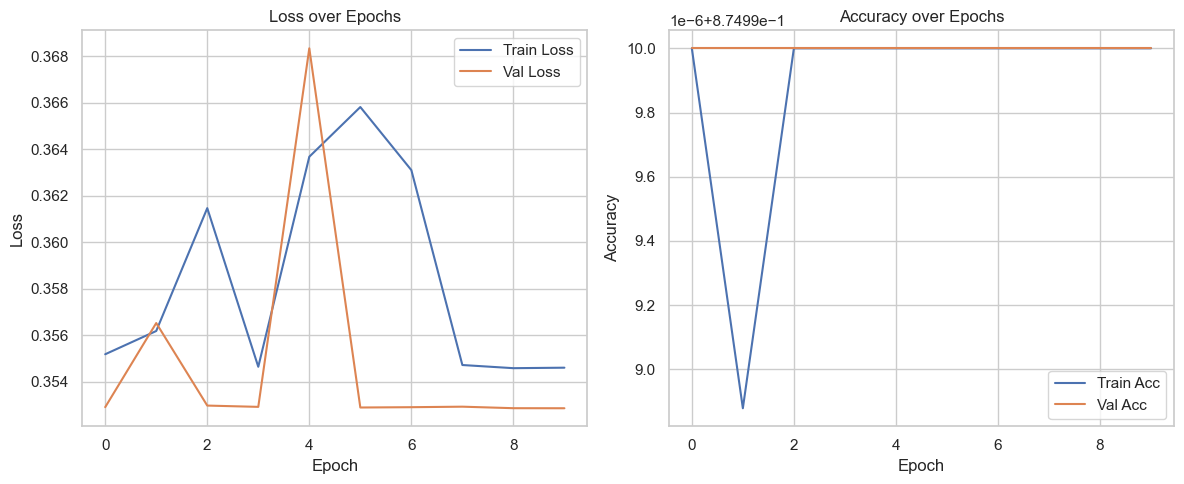

Model training complete! You can now use model.predict_node() for scheduling decisions.


In [57]:
# Initialize and train model
print("Training model...")
num_node_features = len(node_to_idx)  # One-hot encoding size
num_task_features = 2  # task_type and compute_time
model = SchedulerGNN(num_node_features, num_task_features)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

train_model(model, graph_data, optimizer, epochs=10)

print("Model training complete! You can now use model.predict_node() for scheduling decisions.")

In [59]:
torch.save(model.state_dict(), "gnn_scheduler_model.pt")

In [ ]:
# Function to make scheduling decisions
def predict_node(model, task_info, current_system_state):
    """Predict the best node for a given task"""
    model.eval()
    with torch.no_grad():
        # Create graph data for current system state
        # (Similar to create_graph_data but for a single instance)
        # Return the node with the highest score
        pass  # Implementation depends on how you represent system state

# Example of model usage:
"""
# In your scheduler:
def placement(self, system_state: SystemState, task: Task) -> Generator:
    # Convert task and system state to required format
    task_info = {
        'task_type': task.type['name'],
        'compute_time': estimate_compute_time(task)
    }

    # Get model prediction
    best_node = predict_node(model, task_info, system_state)

    # Use the prediction
    task.execution_node = best_node.node_name
    return best_node
"""